# Correct Folding in Deformation Fields — Serial

Test the **serial** iterative SLSQP correction on 2D slices extracted from a
3D displacement field.  Two modes:

1. **Synthetic test case** (default) — generates a small 3D warp volume
   with deliberate folding in selected slices.  No external data needed.
2. **ANTs / NIfTI warp** — load a real `.nii.gz` displacement field from
   ANTs registration and correct slices with negative Jacobians.

**Pipeline per slice:**
1. Extract one axial slice → convert to `(3, 1, H, W)` with `[dz=0, dy, dx]`
2. Compute Jacobian determinant, report negative-Jdet pixels
3. Run `iterative_serial` to correct folding
4. Visualise before/after grids
5. (Optional) Write corrected slices back and save NIfTI

## Imports

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import os
import time

import numpy as np
import matplotlib.pyplot as plt

from dvfopt import jacobian_det2D, iterative_serial, scale_dvf
from dvfopt.viz import plot_grid_before_afterfrom benchmark_utils import (
    get_output_dir, save_figure, save_results_csv, save_summary_json, log_run_header, log_run_footer, results_to_rows, show_and_save, reset_figure_counter,
)


In [ ]:
METHOD = "slsqp"
NOTEBOOK_NAME = "3d-slices-serial"
OUTPUT_DIR = get_output_dir(METHOD, NOTEBOOK_NAME, base="../output")
reset_figure_counter()
summary = log_run_header(METHOD, NOTEBOOK_NAME, OUTPUT_DIR)


## Configuration

Set `USE_SYNTHETIC = True` to run with a generated test volume (no files
needed).  Set it to `False` and fill in `WARP_PATH` to load a real NIfTI
displacement field.

In [2]:
# --- Mode: synthetic test case or real NIfTI ---
USE_SYNTHETIC = True

# --- Path to ANTs warp (only used when USE_SYNTHETIC = False) ---
WARP_PATH = "path/to/ants_warp.nii.gz"

# --- Output directory for corrected results ---
OUTPUT_DIR = "../output/ants_corrections"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Jacobian determinant threshold ---
JDET_THRESHOLD = 0.01

# --- Slices to correct (axial slice indices) ---
# Set to None to auto-detect all slices with negative Jacobians
SLICE_INDICES = None   # e.g. [90, 200, 350] or None for auto-detect

# --- Downscale factor (1.0 = full resolution, 0.2 = 20%) ---
SCALE_FACTOR = 1.0

# --- Slice labels (synthetic test case) ---
SLICE_LABELS = [
    "crossing blobs", "tanh pinch", "sine fold",
    "radial implosion", "y-squeeze", "local push",
]


## Load or generate the 3D warp

* **Synthetic mode** creates a `(40, 40, 6)` volume.  Each axial slice
  contains a different folding pattern, all of which produce negative Jacobians:
  - **Slice 0 — Crossing blobs:** two Gaussian blobs swap positions along both axes
  - **Slice 1 — Tanh pinch:** smooth compression along y via a tanh gradient
  - **Slice 2 — Sine fold:** sinusoidal x-displacement with period W/2 folds the grid repeatedly
  - **Slice 3 — Radial implosion:** strong inward Gaussian field collapses toward center
  - **Slice 4 — Y-squeeze:** top/bottom halves pushed strongly toward center-y
  - **Slice 5 — Local push:** a small Gaussian blob explodes outward, folding with neighbours
* **NIfTI mode** loads an ANTs displacement field and converts from
  ITK `(x,y,z)` to internal `[dz, dy, dx]`.


In [3]:
nii = None
warp_data = None

if USE_SYNTHETIC:
    H, W, D = 30, 30, 6  # 40, 40, 6
    yy, xx = np.mgrid[0:H, 0:W].astype(float)
    cy, cx = H / 2.0, W / 2.0

    warp_zyx = np.zeros((3, H, W, D), dtype=np.float64)

    # Slice 0: Crossing blobs — two Gaussian blobs swap positions
    ra = np.sqrt((yy - H*0.3)**2 + (xx - W*0.3)**2)
    rb = np.sqrt((yy - H*0.7)**2 + (xx - W*0.7)**2)
    ma = (ra < H*0.15).astype(float)
    mb = (rb < H*0.15).astype(float)
    warp_zyx[1, :, :, 0] = ma * H*0.4 - mb * H*0.4
    warp_zyx[2, :, :, 0] = ma * W*0.4 - mb * W*0.4

    # Slice 1: Tanh pinch — smooth y-compression, dJ/dy < -1 at centre
    warp_zyx[1, :, :, 1] = -(H * 0.15) * np.tanh(0.3 * (yy - cy))

    # Slice 2: Sine fold — x-displacement with period W/2 creates repeated folds
    warp_zyx[2, :, :, 2] = (W * 0.2) * np.sin(4 * np.pi * xx / W)

    # Slice 3: Radial implosion — strong inward Gaussian field
    r3 = np.sqrt((yy - cy)**2 + (xx - cx)**2) + 1e-6
    angle3 = np.arctan2(yy - cy, xx - cx)
    strength3 = np.exp(-r3**2 / (2 * (H*0.2)**2)) * H * 0.7
    warp_zyx[1, :, :, 3] = -strength3 * np.sin(angle3)
    warp_zyx[2, :, :, 3] = -strength3 * np.cos(angle3)

    # Slice 4: Y-squeeze — top and bottom halves pushed toward centre-y
    warp_zyx[1, :, :, 4] = (
        np.where(yy < cy, H*0.25, -H*0.25)
        * np.exp(-((yy - cy) / (H*0.15))**2)
    )

    # Slice 5: Local push — small blob explodes outward, folding with neighbours
    r5 = np.sqrt((yy - H*0.4)**2 + (xx - W*0.4)**2) + 1e-6
    strength5 = np.exp(-r5**2 / (2*(H*0.08)**2)) * H * 0.8
    warp_zyx[1, :, :, 5] = strength5 * (yy - H*0.4) / r5
    warp_zyx[2, :, :, 5] = strength5 * (xx - W*0.4) / r5

    print(f"Generated synthetic warp: (3, {H}, {W}, {D})")
    for z in range(D):
        dy_s = warp_zyx[1, :, :, z]
        dx_s = warp_zyx[2, :, :, z]
        phi_z = np.stack([dy_s, dx_s])
        from dvfopt import jacobian_det2D as _jd
        jac_z = _jd(phi_z)
        n_neg = int((jac_z <= 0).sum())
        print(f"  slice {z} ({SLICE_LABELS[z]}): neg_jdet={n_neg}  min={float(jac_z.min()):+.4f}")

else:
    import nibabel as nib
    nii = nib.load(WARP_PATH)
    warp_data = nii.get_fdata()
    print(f"Loaded: {WARP_PATH}")
    print(f"  NIfTI shape : {nii.shape}")
    print(f"  Data shape  : {warp_data.shape}")
    print(f"  Voxel size  : {nii.header.get_zooms()}")

    if warp_data.ndim == 5 and warp_data.shape[3] == 1:
        warp_data = warp_data[:, :, :, 0, :]
        print(f"  Squeezed 5D to 4D: {warp_data.shape}")

    assert warp_data.ndim == 4 and warp_data.shape[-1] == 3, (
        f"Expected (X, Y, Z, 3), got {warp_data.shape}"
    )

    warp_zyx = np.stack([
        warp_data[..., 2],
        warp_data[..., 1],
        warp_data[..., 0],
    ], axis=0)

    print(f"Internal shape (3, X, Y, Z): {warp_zyx.shape}")
    print(f"  dz: [{warp_zyx[0].min():.3f}, {warp_zyx[0].max():.3f}]")
    print(f"  dy: [{warp_zyx[1].min():.3f}, {warp_zyx[1].max():.3f}]")
    print(f"  dx: [{warp_zyx[2].min():.3f}, {warp_zyx[2].max():.3f}]")


Generated synthetic warp: (3, 30, 30, 6)
  slice 0 (crossing blobs): neg_jdet=42  min=-11.0000
  slice 1 (tanh pinch): neg_jdet=90  min=-0.3109
  slice 2 (sine fold): neg_jdet=360  min=-1.3871
  slice 3 (radial implosion): neg_jdet=205  min=-21.0700
  slice 4 (y-squeeze): neg_jdet=60  min=-6.1386
  slice 5 (local push): neg_jdet=112  min=-35.8583


## Deformation field convention

Displacement fields are **pull-back (backward) maps**: for every voxel
position in **fixed space** the warp gives the displacement to the corresponding
location in **moving space**.  This is identical to the dvfopt convention
(`[dz, dy, dx]` in fixed-space coordinates, pull-back semantics).

The synthetic slices below follow the same convention: each slice shows how
fixed-space grid nodes are displaced when sampling the moving image.


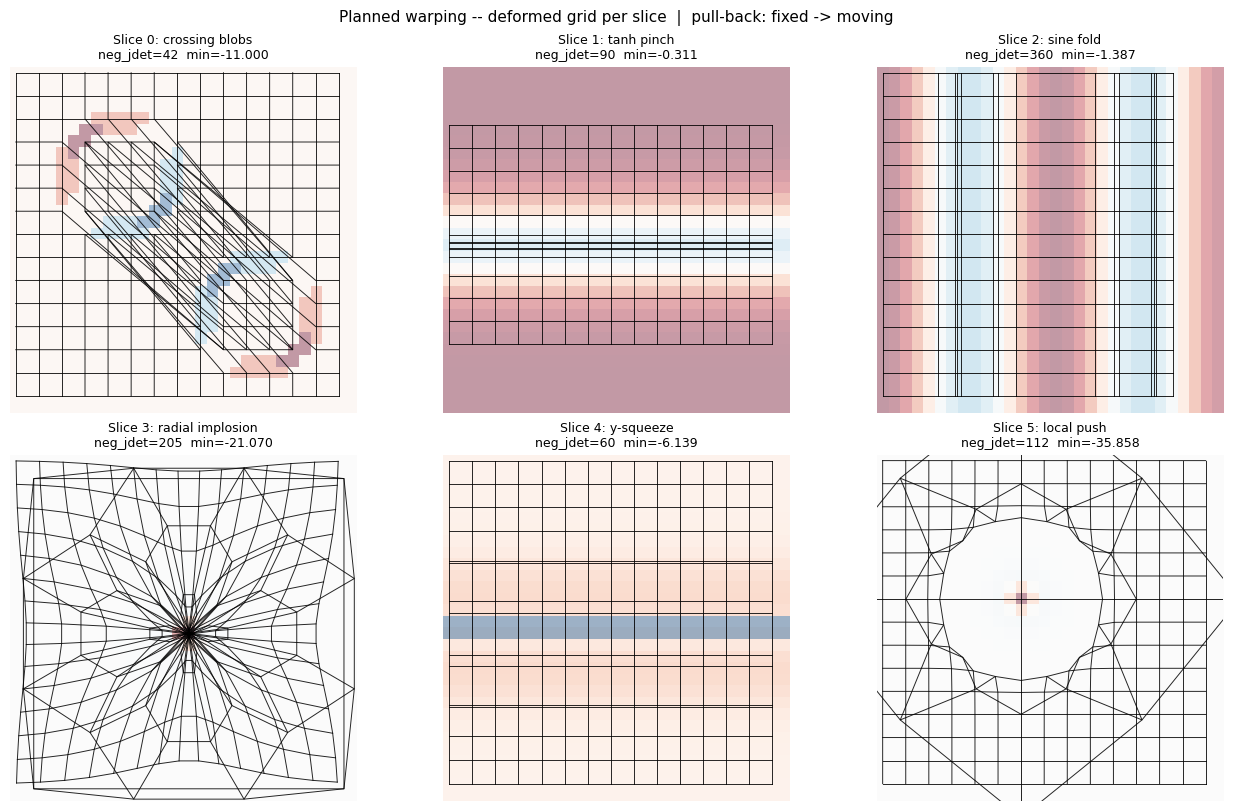

In [4]:
# Show the planned warping for each slice as a deformed grid
# (pull-back: pull-back displacement field: for each fixed-space voxel, offset to the sample location)
stride = 2   # plot every 2nd grid line for clarity on 40x40

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)

for z, ax in enumerate(axes.flat):
    dy = warp_zyx[1, :, :, z]
    dx = warp_zyx[2, :, :, z]

    rows = np.arange(0, H, stride)
    cols = np.arange(0, W, stride)
    rr, cc = np.meshgrid(rows, cols, indexing="ij")
    def_y = rr + dy[rr, cc]
    def_x = cc + dx[rr, cc]

    phi_z = np.stack([dy, dx])
    jac_z = np.squeeze(jacobian_det2D(phi_z))
    n_neg = int((jac_z <= 0).sum())
    vmax = max(abs(float(jac_z.min())), float(jac_z.max()), 1.0)
    # No extent: imshow maps array[i,j] -> pixel (x=j, y=i) in integer coords
    ax.imshow(jac_z, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
              alpha=0.4, origin="upper")

    for i in range(def_y.shape[0]):
        ax.plot(def_x[i, :], def_y[i, :], "k-", lw=0.7, alpha=0.85)
    for j in range(def_y.shape[1]):
        ax.plot(def_x[:, j], def_y[:, j], "k-", lw=0.7, alpha=0.85)

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)
    subtitle = f"neg_jdet={n_neg}  min={float(jac_z.min()):+.3f}"
    ax.set_title(f"Slice {z}: {SLICE_LABELS[z]}" + chr(10) + subtitle, fontsize=9)
    ax.set_aspect("equal")
    ax.axis("off")

plt.suptitle(
    "Planned warping -- deformed grid per slice  |  pull-back displacement field",
    fontsize=11,
)
show_and_save(OUTPUT_DIR)


## Identify slices with negative Jacobians

In [5]:
n_slices = warp_zyx.shape[3]  # Z dimension (axial slices)

# Survey every slice for negative Jacobians
slice_neg_counts = {}
print(f"Scanning {n_slices} axial slices for negative Jacobians...")

for z in range(n_slices):
    # Extract 2D slice: (3, X, Y) â†’ (2, H, W) with [dy, dx]
    dy_slice = warp_zyx[1, :, :, z]
    dx_slice = warp_zyx[2, :, :, z]
    phi_2d = np.stack([dy_slice, dx_slice])  # (2, H, W)
    jac = jacobian_det2D(phi_2d)
    n_neg = int((jac <= 0).sum())
    if n_neg > 0:
        slice_neg_counts[z] = n_neg

print(f"\nSlices with negative Jacobians: {len(slice_neg_counts)} / {n_slices}")
if slice_neg_counts:
    # Show top 20 worst slices
    sorted_slices = sorted(slice_neg_counts.items(), key=lambda x: -x[1])
    print(f"\n{'Slice':>6s}  {'Neg Jdet':>10s}")
    print("-" * 20)
    for z, count in sorted_slices[:20]:
        print(f"{z:>6d}  {count:>10d}")
    if len(sorted_slices) > 20:
        print(f"  ... and {len(sorted_slices) - 20} more slices")

Scanning 6 axial slices for negative Jacobians...

Slices with negative Jacobians: 6 / 6

 Slice    Neg Jdet
--------------------
     2         360
     3         205
     5         112
     1          90
     4          60
     0          42


## Helper: extract a 2D deformation from an axial slice

In [6]:
def extract_slice(warp_zyx, slice_idx, scale_factor=1.0):
    """Extract an axial slice from the 3D warp as a (3, 1, H, W) deformation.

    Parameters
    ----------
    warp_zyx : ndarray, shape (3, X, Y, Z)
        Full 3D warp in [dz, dy, dx] convention.
    slice_idx : int
        Axial slice index along the Z axis.
    scale_factor : float
        If < 1.0, downscale the slice for faster correction.

    Returns
    -------
    deformation : ndarray, shape (3, 1, H, W)
        2D deformation field with dz=0.
    """
    dz_slice = np.zeros_like(warp_zyx[0, :, :, slice_idx])
    dy_slice = warp_zyx[1, :, :, slice_idx].copy()
    dx_slice = warp_zyx[2, :, :, slice_idx].copy()

    H, W = dy_slice.shape
    deformation = np.stack([
        dz_slice[np.newaxis, :, :],
        dy_slice[np.newaxis, :, :],
        dx_slice[np.newaxis, :, :],
    ])  # (3, 1, H, W)

    if scale_factor < 1.0:
        new_H = max(2, int(H * scale_factor))
        new_W = max(2, int(W * scale_factor))
        deformation = scale_dvf(deformation, (new_H, new_W))
        print(f"  Downscaled {H}x{W} â†’ {new_H}x{new_W}")

    return deformation

## Helper: run correction and visualise

In [7]:
def show_jdet_map(jac, title, ax):
    jac2d = np.squeeze(jac)
    vmax = max(abs(float(jac2d.min())), abs(float(jac2d.max())), 1.0)
    im = ax.imshow(jac2d, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    n_neg = int((jac2d <= 0).sum())
    stats = f"neg={n_neg}  min={jac2d.min():+.3f}  max={jac2d.max():+.3f}"
    ax.set_title(title + chr(10) + stats, fontsize=9)
    ax.axis("off")
    return im


def correct_and_show(key, deformation, **kwargs):
    H, W = deformation.shape[-2:]
    phi_init = np.stack([deformation[1, 0], deformation[2, 0]])
    jac_init = jacobian_det2D(phi_init)
    n_neg = int((jac_init <= 0).sum())
    n_below = int((jac_init <= JDET_THRESHOLD).sum())
    min_jdet = float(jac_init.min())

    sep = "=" * 70
    print()
    print(sep)
    print(f"  {key}  |  {H}x{W}")
    print(f"  Before:  neg_jdet={n_neg}  below_thresh={n_below}  min_jdet={min_jdet:+.6f}")
    print(sep)

    if n_neg == 0:
        print("  No negative Jacobians - skipping correction.")
        fig, ax = plt.subplots(1, 1, figsize=(4, 3.5), constrained_layout=True)
        show_jdet_map(jac_init, f"{key} - Jdet (no folding)", ax)
        show_and_save(OUTPUT_DIR)
        return None

    # Jdet map BEFORE (compact single panel)
    fig, ax = plt.subplots(1, 1, figsize=(4, 3.5), constrained_layout=True)
    show_jdet_map(jac_init, f"{key} - Before correction", ax)
    plt.suptitle(f"{key} - Jacobian Determinant (before correction)", fontsize=11)
    show_and_save(OUTPUT_DIR)

    t0 = time.perf_counter()
    phi = iterative_serial(
        deformation.copy(), verbose=1, threshold=JDET_THRESHOLD, **kwargs
    )
    elapsed = time.perf_counter() - t0

    jac_final = jacobian_det2D(phi)
    n_neg_final = int((jac_final <= 0).sum())
    n_below_final = int((jac_final <= JDET_THRESHOLD).sum())
    min_jdet_final = float(jac_final.min())
    l2 = float(np.sqrt(np.sum((phi - phi_init) ** 2)))

    print(f"  After:   neg_jdet={n_neg} -> {n_neg_final}  "
          f"below_thresh={n_below} -> {n_below_final}  "
          f"min_jdet={min_jdet:+.4f} -> {min_jdet_final:+.4f}  "
          f"L2={l2:.4f}  time={elapsed:.2f}s")

    # Jdet maps BEFORE and AFTER side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
    im = show_jdet_map(jac_init, f"{key} - Before correction", axes[0])
    show_jdet_map(jac_final, f"{key} - After correction", axes[1])
    plt.colorbar(im, ax=axes, shrink=0.8, label="Jacobian det")
    plt.suptitle(f"{key} - Jacobian Determinant Before vs After", fontsize=11)
    show_and_save(OUTPUT_DIR)

    plot_grid_before_after(deformation, phi, title=key)
    return phi

## Select slices to correct

In [8]:
if SLICE_INDICES is None:
    # Auto: pick all slices with negative Jacobians
    slices_to_correct = sorted(slice_neg_counts.keys())
    print(f"Auto-selected {len(slices_to_correct)} slices with negative Jacobians")
else:
    slices_to_correct = SLICE_INDICES
    print(f"User-selected slices: {slices_to_correct}")

print(f"Scale factor: {SCALE_FACTOR}")

Auto-selected 6 slices with negative Jacobians
Scale factor: 1.0


## Run corrections


  slice_0000  |  30x30
  Before:  neg_jdet=42  below_thresh=42  min_jdet=-11.000000


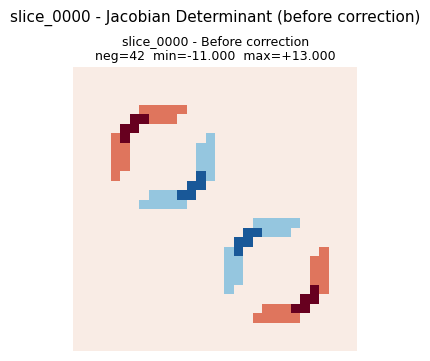

[init] Grid 30x30  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 42  |  min Jdet: -11.000000
[iter    1]  fix ( 11, 13)  win 14x14  neg_jdet    21  min_jdet -11.000000  L2 20.5372  sub-iters 2
[iter    2]  fix ( 17, 18)  win 26x26  neg_jdet     0  min_jdet +0.010000  L2 27.3004  sub-iters 9
[done] All Jdet > threshold after iter 2

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 30 x 30
  Iterations       : 2
  Neg-Jdet     42 ->     0
  Min Jdet  -11.000000 -> +0.010000
  L2 error         : 27.300360
  Time             : 64.56s
  After:   neg_jdet=42 -> 0  below_thresh=42 -> 57  min_jdet=-11.0000 -> +0.0100  L2=27.3004  time=64.56s


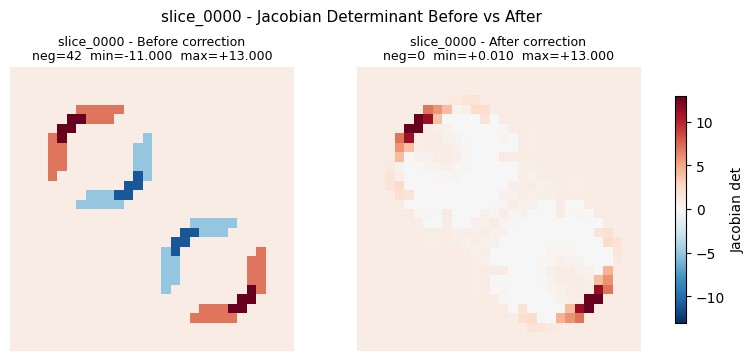

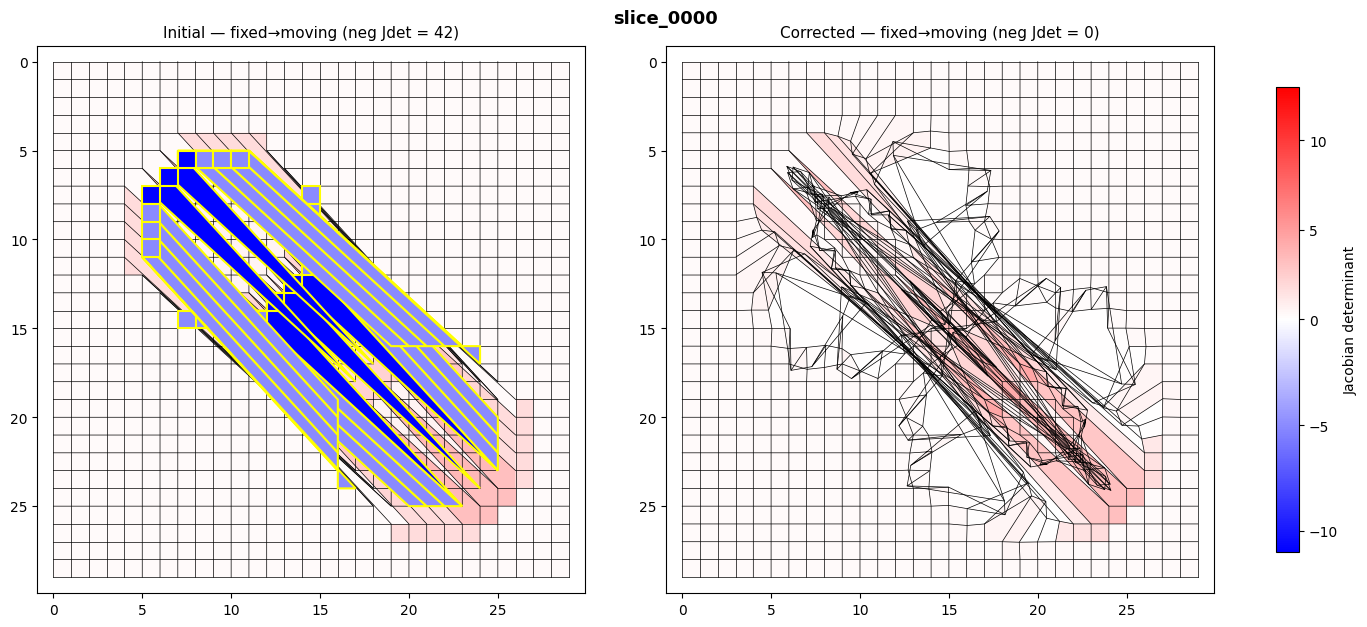


  slice_0001  |  30x30
  Before:  neg_jdet=90  below_thresh=90  min_jdet=-0.310907


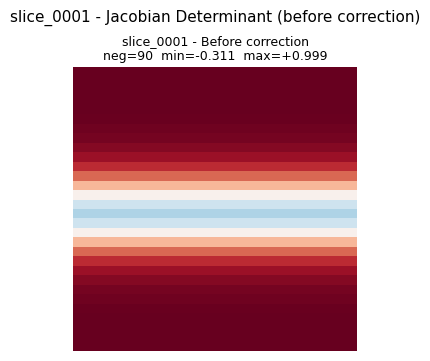

[init] Grid 30x30  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 90  |  min Jdet: -0.310907
[iter    1]  fix ( 15,  0)  win 7x30  neg_jdet     0  min_jdet +0.010000  L2 4.6338  sub-iters 2
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 30 x 30
  Iterations       : 1
  Neg-Jdet     90 ->     0
  Min Jdet  -0.310907 -> +0.010000
  L2 error         : 4.633764
  Time             : 0.65s
  After:   neg_jdet=90 -> 0  below_thresh=90 -> 62  min_jdet=-0.3109 -> +0.0100  L2=4.6338  time=0.65s


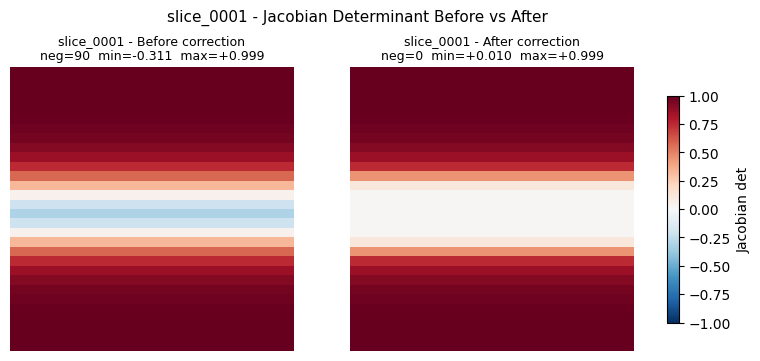

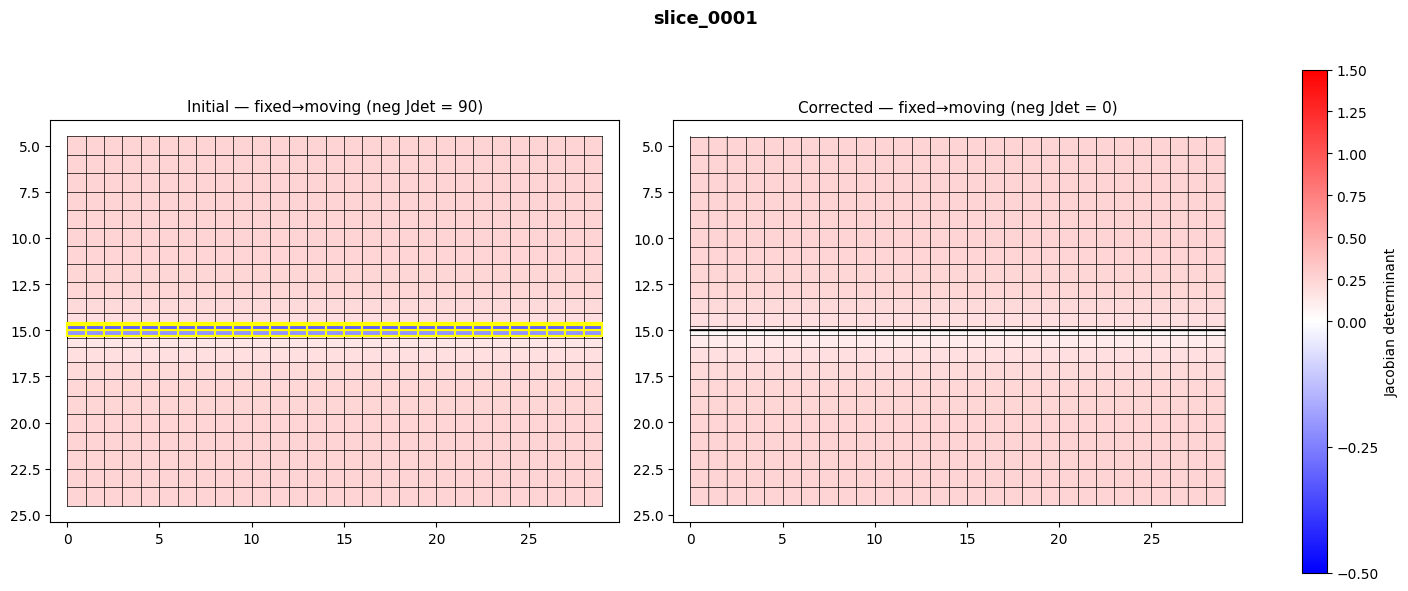


  slice_0002  |  30x30
  Before:  neg_jdet=360  below_thresh=360  min_jdet=-1.387091


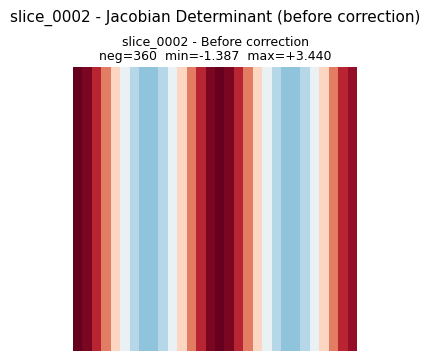

[init] Grid 30x30  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 360  |  min Jdet: -1.387091
[iter    1]  fix (  0, 23)  win 30x14  neg_jdet   180  min_jdet -1.387091  L2 27.3058  sub-iters 3
[iter    2]  fix (  0,  8)  win 30x12  neg_jdet     0  min_jdet +0.010000  L2 38.5624  sub-iters 3
[done] All Jdet > threshold after iter 2

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 30 x 30
  Iterations       : 2
  Neg-Jdet    360 ->     0
  Min Jdet  -1.387091 -> +0.010000
  L2 error         : 38.562376
  Time             : 216.01s
  After:   neg_jdet=360 -> 0  below_thresh=360 -> 231  min_jdet=-1.3871 -> +0.0100  L2=38.5624  time=216.01s


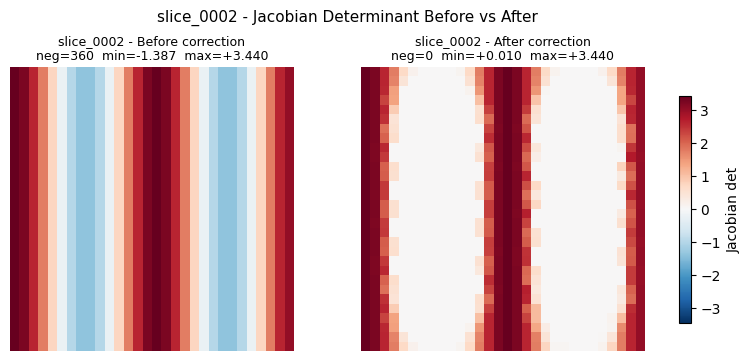

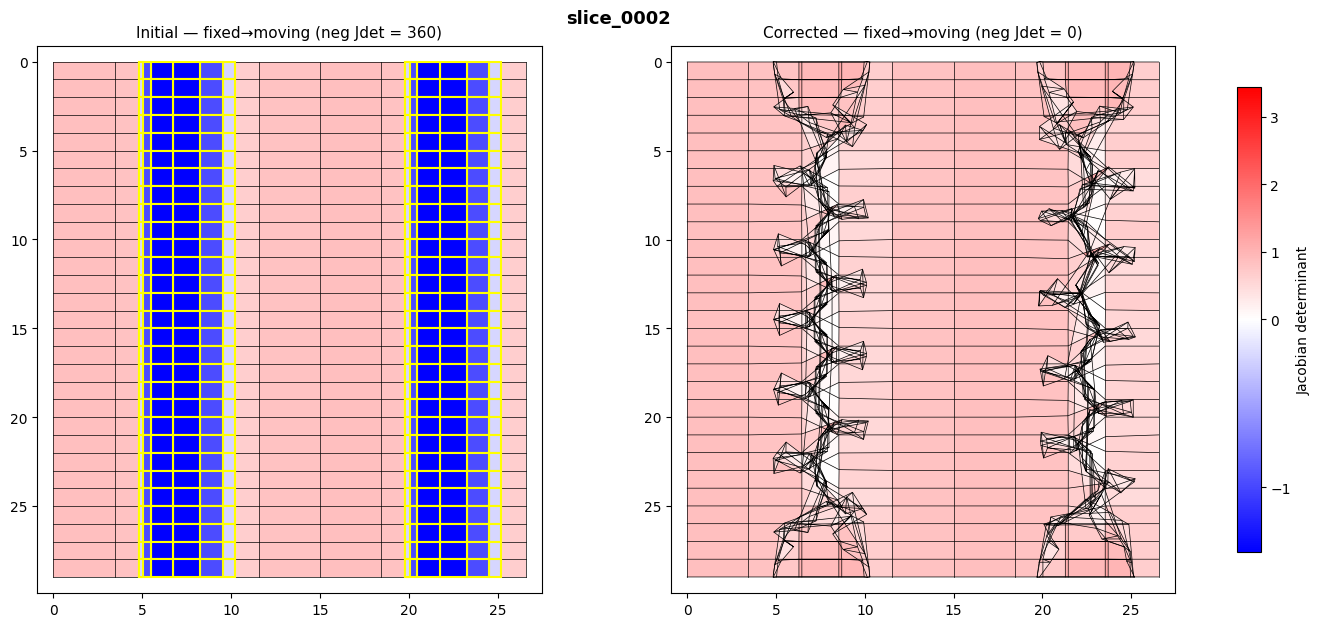


  slice_0003  |  30x30
  Before:  neg_jdet=205  below_thresh=205  min_jdet=-21.070030


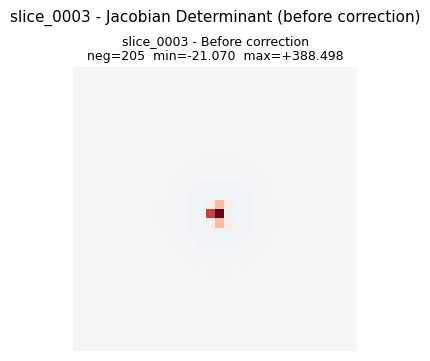

[init] Grid 30x30  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 205  |  min Jdet: -21.070030
[iter    1]  fix ( 15, 16)  win 19x19  neg_jdet     0  min_jdet +0.010000  L2 75.2369  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 30 x 30
  Iterations       : 1
  Neg-Jdet    205 ->     0
  Min Jdet  -21.070030 -> +0.010000
  L2 error         : 75.236913
  Time             : 142.59s
  After:   neg_jdet=205 -> 0  below_thresh=205 -> 156  min_jdet=-21.0700 -> +0.0100  L2=75.2369  time=142.59s


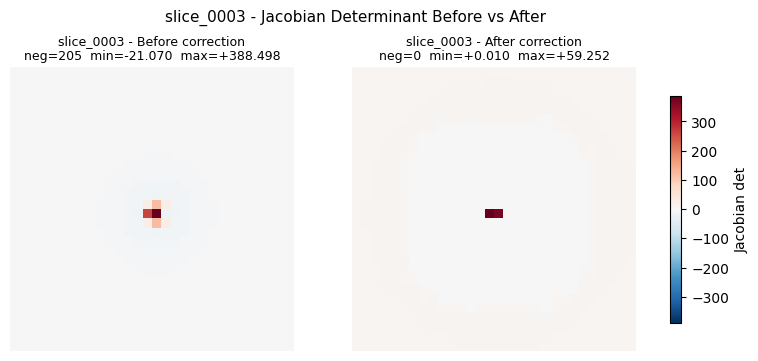

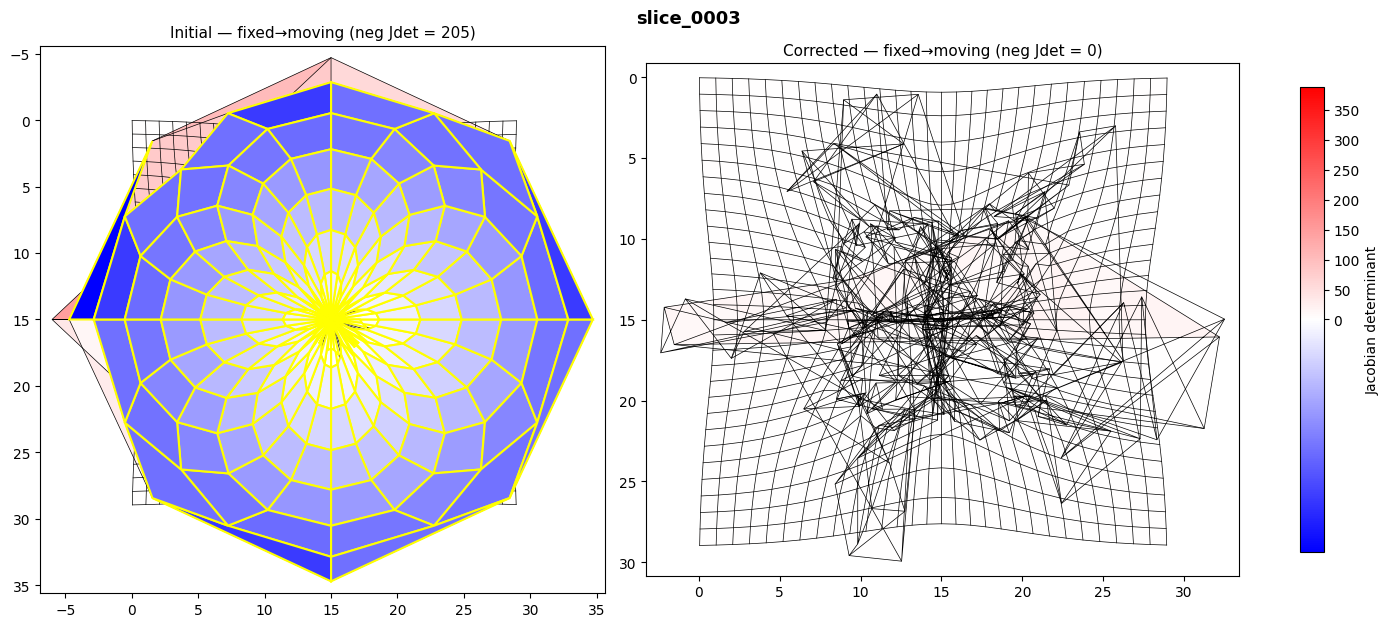


  slice_0004  |  30x30
  Before:  neg_jdet=60  below_thresh=60  min_jdet=-6.138626


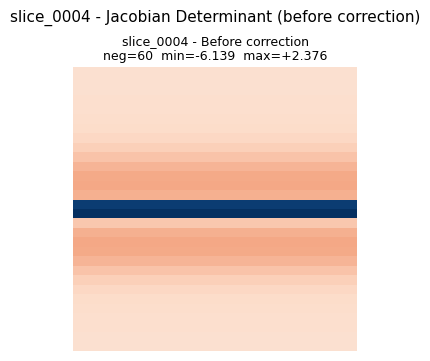

[init] Grid 30x30  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 60  |  min Jdet: -6.138626
[iter    1]  fix ( 15,  0)  win 10x30  neg_jdet     0  min_jdet +0.010000  L2 37.7300  sub-iters 4
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 30 x 30
  Iterations       : 1
  Neg-Jdet     60 ->     0
  Min Jdet  -6.138626 -> +0.010000
  L2 error         : 37.729987
  Time             : 12.15s
  After:   neg_jdet=60 -> 0  below_thresh=60 -> 62  min_jdet=-6.1386 -> +0.0100  L2=37.7300  time=12.15s


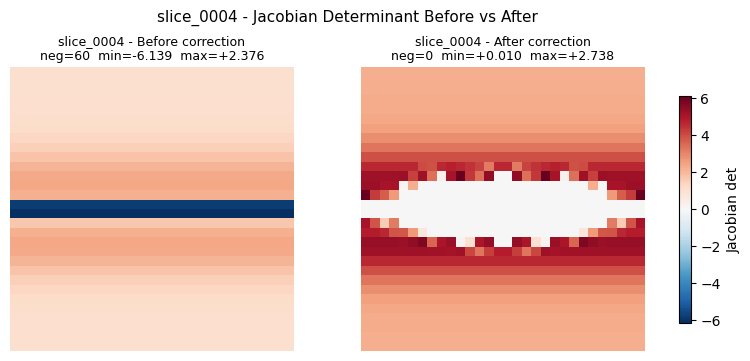

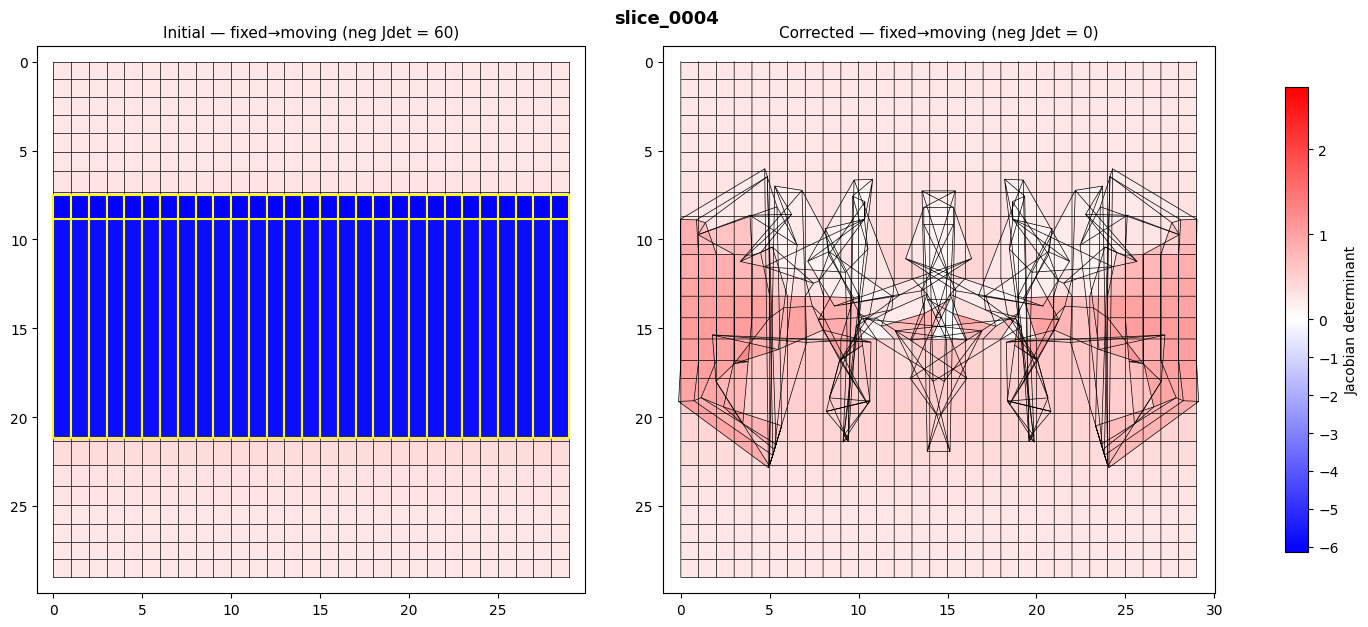


  slice_0005  |  30x30
  Before:  neg_jdet=112  below_thresh=112  min_jdet=-35.858328


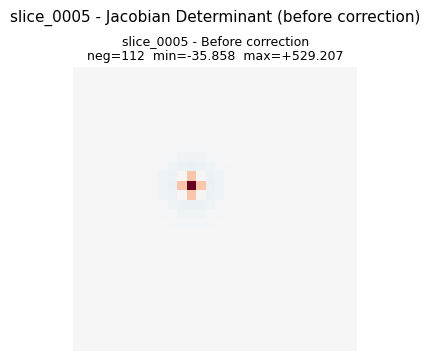

[init] Grid 30x30  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 112  |  min Jdet: -35.858328
[iter    1]  fix ( 10, 12)  win 17x17  neg_jdet     0  min_jdet +0.010000  L2 52.9394  sub-iters 2
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 30 x 30
  Iterations       : 1
  Neg-Jdet    112 ->     0
  Min Jdet  -35.858328 -> +0.010000
  L2 error         : 52.939366
  Time             : 29.37s
  After:   neg_jdet=112 -> 0  below_thresh=112 -> 108  min_jdet=-35.8583 -> +0.0100  L2=52.9394  time=29.37s


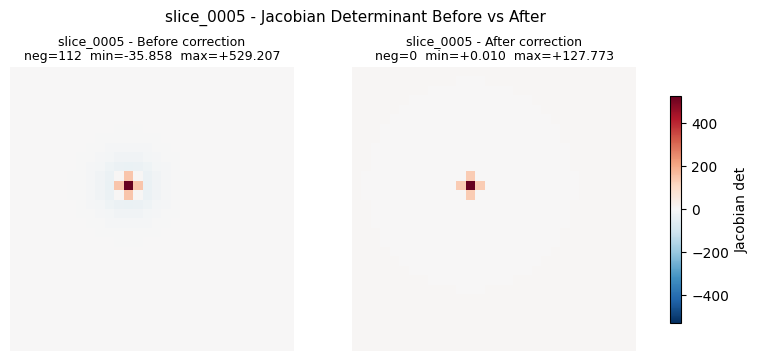

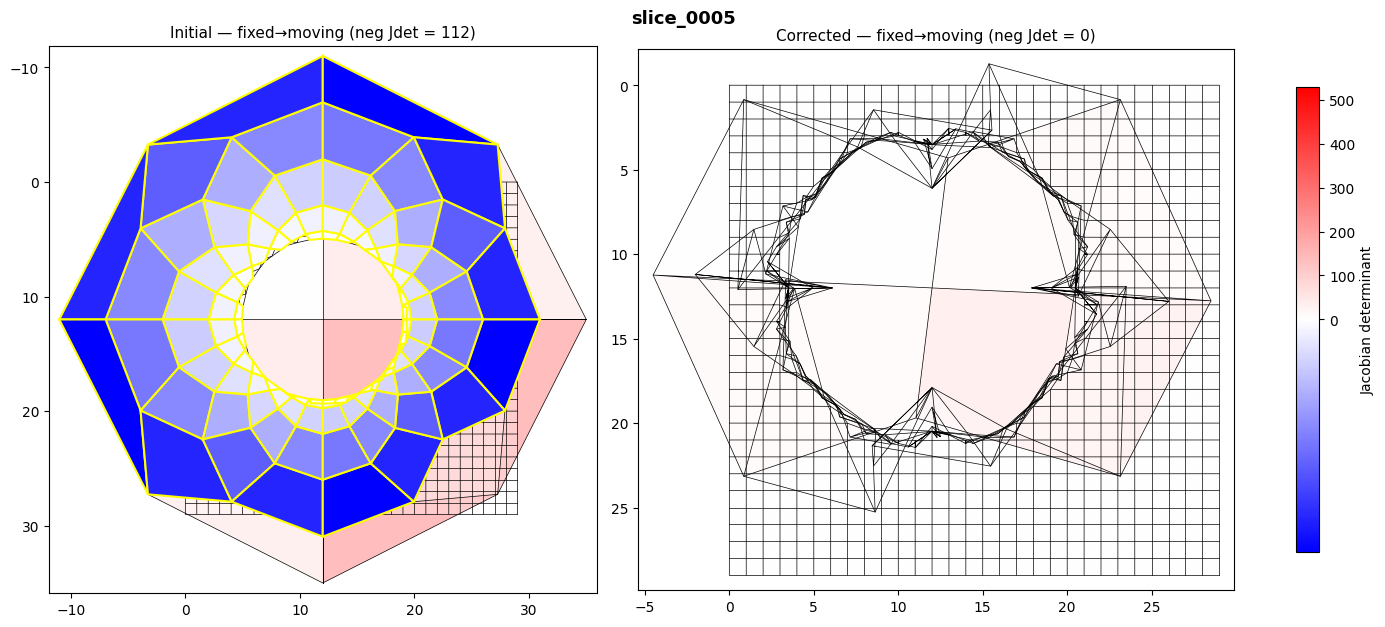


Corrected 6 / 6 slices


In [9]:
corrected_slices = {}  # slice_idx â†’ corrected phi (2, H, W)

for z in slices_to_correct:
    key = f"slice_{z:04d}"
    deformation = extract_slice(warp_zyx, z, scale_factor=SCALE_FACTOR)
    phi = correct_and_show(key, deformation)
    if phi is not None:
        corrected_slices[z] = phi

print(f"\nCorrected {len(corrected_slices)} / {len(slices_to_correct)} slices")

## (Optional) Write corrected slices back into the 3D warp and save

Replace the corrected `[dy, dx]` channels in each slice of the original
warp and write out a new NIfTI file.  Only runs if there are corrected
slices and `SCALE_FACTOR == 1.0` (no downscaling).

In [10]:
if not corrected_slices:
    print("No slices were corrected â€” nothing to save.")
elif USE_SYNTHETIC:
    # Save corrected warp_zyx as .npy
    warp_out = warp_zyx.copy()
    for z, phi in corrected_slices.items():
        warp_out[1, :, :, z] = phi[0]  # dy
        warp_out[2, :, :, z] = phi[1]  # dx
    out_path = os.path.join(OUTPUT_DIR, "warp_corrected.npy")
    np.save(out_path, warp_out)
    print(f"Saved corrected warp to: {out_path}")
    print(f"  Slices modified: {sorted(corrected_slices.keys())}")
elif SCALE_FACTOR == 1.0:
    import nibabel as nib
    warp_corrected = warp_data.copy()  # (X, Y, Z, 3) in ITK xyz order
    for z, phi in corrected_slices.items():
        warp_corrected[:, :, z, 0] = phi[1]  # dx â†’ ITK x
        warp_corrected[:, :, z, 1] = phi[0]  # dy â†’ ITK y
    out_path = os.path.join(OUTPUT_DIR, "warp_corrected.nii.gz")
    corrected_nii = nib.Nifti1Image(warp_corrected, nii.affine, nii.header)
    nib.save(corrected_nii, out_path)
    print(f"Saved corrected NIfTI to: {out_path}")
    print(f"  Slices modified: {sorted(corrected_slices.keys())}")
else:
    print(f"Skipping NIfTI save: scale_factor={SCALE_FACTOR} (only saves at full resolution)")

Saved corrected warp to: ../output/ants_corrections\warp_corrected.npy
  Slices modified: [0, 1, 2, 3, 4, 5]


## Summary

In [11]:
print(f"{'Slice':>8s}  {'Size':>10s}  {'Neg init':>10s}  {'Neg final':>10s}  {'Min Jdet':>10s}")
print("-" * 55)

for z in sorted(corrected_slices.keys()):
    phi = corrected_slices[z]
    H, W = phi.shape[-2:]
    jac = jacobian_det2D(phi)
    n_neg = int((jac <= 0).sum())
    min_j = float(jac.min())

    # Initial stats from the original warp
    dy_orig = warp_zyx[1, :, :, z]
    dx_orig = warp_zyx[2, :, :, z]
    jac_orig = jacobian_det2D(np.stack([dy_orig, dx_orig]))
    n_neg_orig = int((jac_orig <= 0).sum())

    print(f"{z:>8d}  {H:>4d}x{W:<4d}  {n_neg_orig:>10d}  {n_neg:>10d}  {min_j:>10.4f}")

   Slice        Size    Neg init   Neg final    Min Jdet
-------------------------------------------------------
       0    30x30            42           0      0.0100
       1    30x30            90           0      0.0100
       2    30x30           360           0      0.0100
       3    30x30           205           0      0.0100
       4    30x30            60           0      0.0100
       5    30x30           112           0      0.0100


In [ ]:
# --- Save results ---
if 'results' in dir() and isinstance(results, dict) and results:
    rows, cols = results_to_rows(results)
    save_results_csv(rows, cols, OUTPUT_DIR)
    summary = log_run_footer(summary, results)
    save_summary_json(summary, OUTPUT_DIR)
elif 'mag_results' in dir():
    rows, cols = results_to_rows(mag_results)
    save_results_csv(rows, cols, OUTPUT_DIR, name='results_magnitude')
    if 'density_results' in dir():
        rows2, cols2 = results_to_rows(density_results)
        save_results_csv(rows2, cols2, OUTPUT_DIR, name='results_density')
    combined = {**mag_results, **density_results} if 'density_results' in dir() else mag_results
    summary = log_run_footer(summary, combined)
    save_summary_json(summary, OUTPUT_DIR)
else:
    save_summary_json(summary, OUTPUT_DIR)
    print('No results dict found; saved summary only.')
